In [45]:
# Instalação de biblioteca para rodar o código
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [4]:
# Criando DataFrame para a leitura do arquivo
df = pd.read_csv("BASE_SUPERMERCADO.csv")
df.head()

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos


In [34]:
# Organizar a quantidade de cada Categoria para melhor avaliação das informações
contar_categorias = df['Categoria'].value_counts().sort_values(ascending=False)
print(contar_categorias)

Categoria
lacteos                       447
belleza-y-cuidado-personal    239
congelados                    235
verduras                       64
instantaneos-y-sopas           57
comidas-preparadas             46
frutas                         19
Name: count, dtype: int64


In [9]:
# Código direto para trazer a média
df['Preco_Normal'].mean()

np.float64(2070.9972899728996)

In [10]:
# Código direto para trazer a mediana
df['Preco_Normal'].median()

1269.0

In [19]:
# Trazendo o Desvio Padrão com código rápido
df.describe().round(0)

,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto
count,1107,1107,1107,1107
mean,2071,522,372,68
std,2961,1340,1239,241
min,0,0,0,0
25%,0,0,0,0
50%,1269,0,0,0
75%,2849,0,0,0
max,19788,14550,18899,4349


In [20]:
# Colocando a "Categoria" como coluna principal e organizando os dados em ordem decrescente na coluna "Preco_Normal"
df.groupby('Categoria')['Preco_Normal'].std().reset_index().sort_values(by='Preco_Normal', ascending=False)

,Categoria,Preco_Normal
5,lacteos,3926
0,belleza-y-cuidado-personal,2210
2,congelados,2112
1,comidas-preparadas,2020
3,frutas,1639
4,instantaneos-y-sopas,1170
6,verduras,1013


Percebe-se que há alguma "inconsistência" nos dados na parte das frutas e lácteos, há um salto entre os "Instantaneos" e as "Frutas" que me chamou a atenção, e posteriormente a outro salto do "Beleza e cuidado pessoal" para os "lacteos". Esses dois estão fazendo com que a mediana fique muito longe da média.

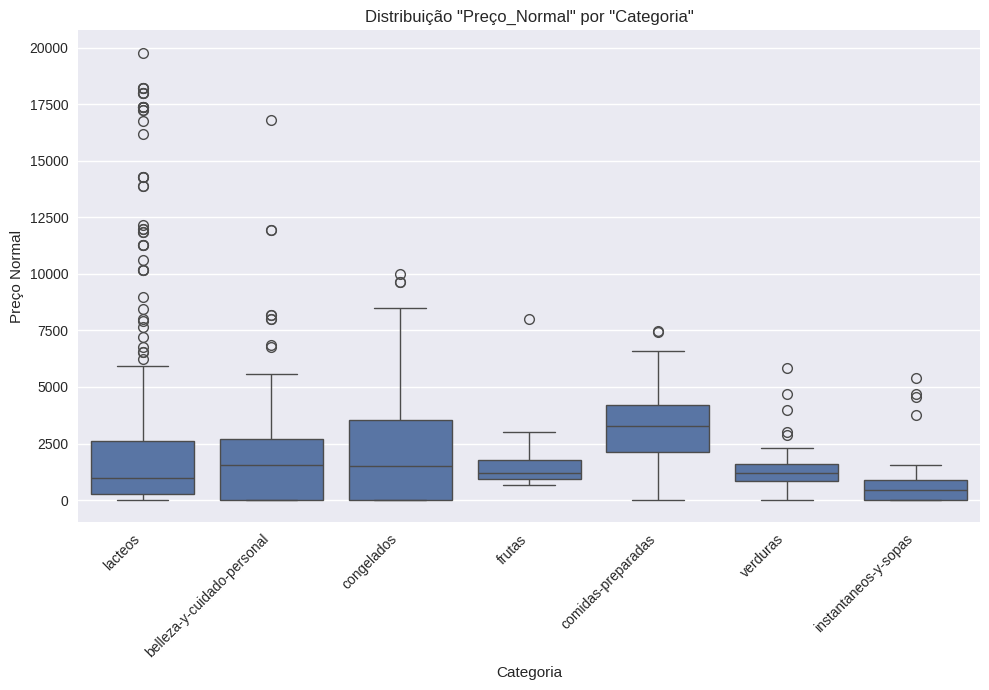

In [48]:
# Definir o estilo do gráfico
plt.style.use('seaborn-v0_8')
# Definir o tamanho da figura
plt.figure(figsize=(10, 7))
# Gerando BoxPlot e definindo os títulos dos eixos
sns.boxplot(x='Categoria', y='Preco_Normal', data=df)
# Título do gráfico
plt.title('Distribuição "Preço_Normal" por "Categoria"')
# Título do eixo x
plt.xlabel('Categoria')
# Título do eixo y
plt.ylabel('Preço Normal')
# Rotacionar o eixo x para melhor leitura das informações
plt.xticks(rotation=45, ha='right')
# Comando para evitar sobreposições das informações
plt.tight_layout()
# Mostrar o gráfico
plt.show()

Existem outliers em todas as categorias, mas as dos lácteos estão em maior quantidade, logo, ele é quem está puxando as métricas para cima. Obs:tendo em vista que há uma quantidade bem maior, 447 lácteos para 239 do segundo exemplo, uma diferença de aproximadamente 46%, mas mesmo assim, há muitos outliers na categoria.


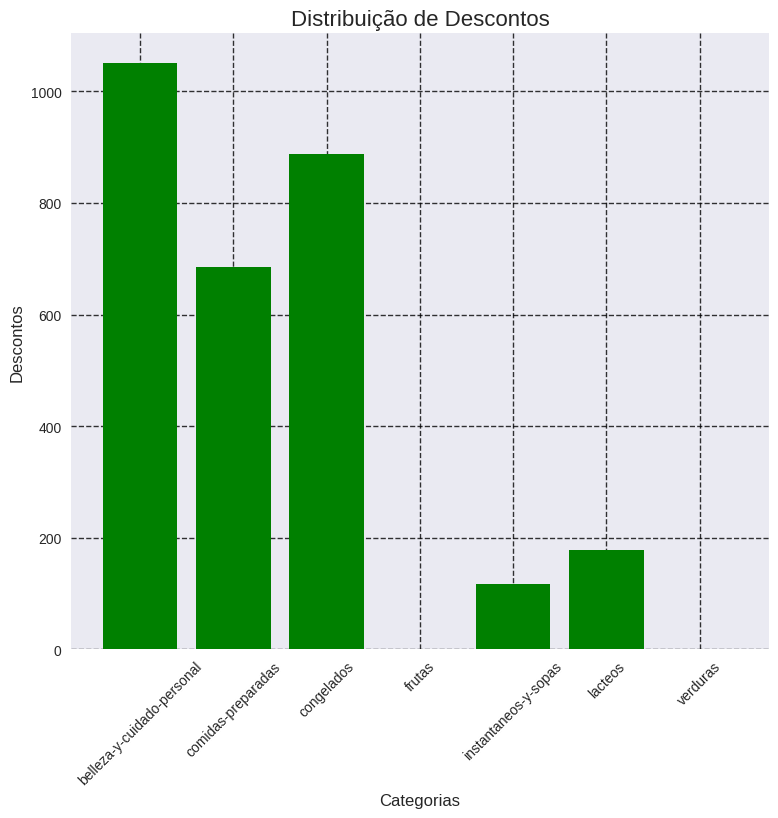

In [43]:
# Criando a figura
plt.figure(figsize=(9, 8))

# Agrupando os dados do DataFrame por profissão e calculando a média do Desconto para cada Categoria
desconto_por_categoria = df.groupby('Categoria')['Preco_Desconto'].mean()

# Indicando os índices do DataFrame
plt.bar(desconto_por_categoria.index, desconto_por_categoria, color='green')

# Adicionando Título
plt.title('Distribuição de Descontos', fontsize=16)

# Adicionando rótulo no Eixo X
plt.xlabel('Categorias', fontsize=12)

# Adicionando rótulo no Eixo Y
plt.ylabel('Descontos', fontsize=12)

# Rotacionar os rótulos do Eixo X em 45 graus
plt.xticks(rotation=45)

# Adicionando grades ao gráfico com estilo de linha (-)
plt.grid(True, linestyle='--', alpha=0.8, color='black')

# Exibindo o gráfico
plt.show()

In [46]:
# Agrupar dados por "Categoria", "Marca" e calcular a "Média de Desconto"
df_grouped = df.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index()

# Criar Treemap Interativo
fig = px.treemap(df_grouped, path=['Categoria', 'Marca'], values='Desconto', title='Média de Desconto por Categoria e Marca', color_continuous_scale='Viridis')

fig.show()